#  **Taller de Imputación de Datos**

Hechamos un vistazo a la base:

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

url = "https://raw.githubusercontent.com/Kalbam/Datos/refs/heads/main/base_imputacion_mixta_1000.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe(include="all"))

        fecha sexo        ciudad nivel_educativo segmento estado_civil  edad  \
0  2024-01-01    F      Medellín             NaN        B  Unión libre  19.0   
1  2024-01-02    F  Barranquilla             NaN        B          NaN  52.0   
2  2024-01-03    M        Bogotá      Secundaria        B    Soltero/a  38.0   
3  2024-01-04    F        Bogotá             NaN        B     Casado/a  57.0   
4  2024-01-05    M          Cali         Técnico        B    Soltero/a  67.0   

    altura_cm     ingresos  gasto_mensual  puntuacion_credito     demanda  
0  161.821754  3574.753806    1832.731832          640.465372  119.202995  
1  167.819566  3163.626815            NaN          533.108430  124.457874  
2  165.756219  2765.672259    1219.535074          491.016910         NaN  
3  160.642670  4320.397345    1908.324816                 NaN  129.426792  
4  151.402909          NaN    1887.385697          610.213994  133.916319  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries,

Identificamos la naturaleza de las variables:

In [18]:
cualitativas = df.select_dtypes(include=['object']).columns
cuantitativas = df.select_dtypes(include=['number']).columns
print("Variables cualitativas:", cualitativas.tolist())
print("Variables cuantitativas:", cuantitativas.tolist())

Variables cualitativas: ['fecha', 'sexo', 'ciudad', 'nivel_educativo', 'segmento', 'estado_civil']
Variables cuantitativas: ['edad', 'altura_cm', 'ingresos', 'gasto_mensual', 'puntuacion_credito', 'demanda']


Para iniciar la imputación, verificamos el porcentaje de nulos:

In [ ]:
import matplotlib.pyplot as plt
import missingno as msno
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
tabla_nulos = pd.DataFrame({"Nulos": faltantes, "Porcentaje": porcentaje})
print(tabla_nulos)

                    Nulos  Porcentaje
fecha                   0         0.0
sexo                   20         2.0
ciudad                 50         5.0
nivel_educativo       100        10.0
segmento              200        20.0
estado_civil          350        35.0
edad                   30         3.0
altura_cm              80         8.0
ingresos              120        12.0
gasto_mensual         250        25.0
puntuacion_credito    500        50.0
demanda               150        15.0


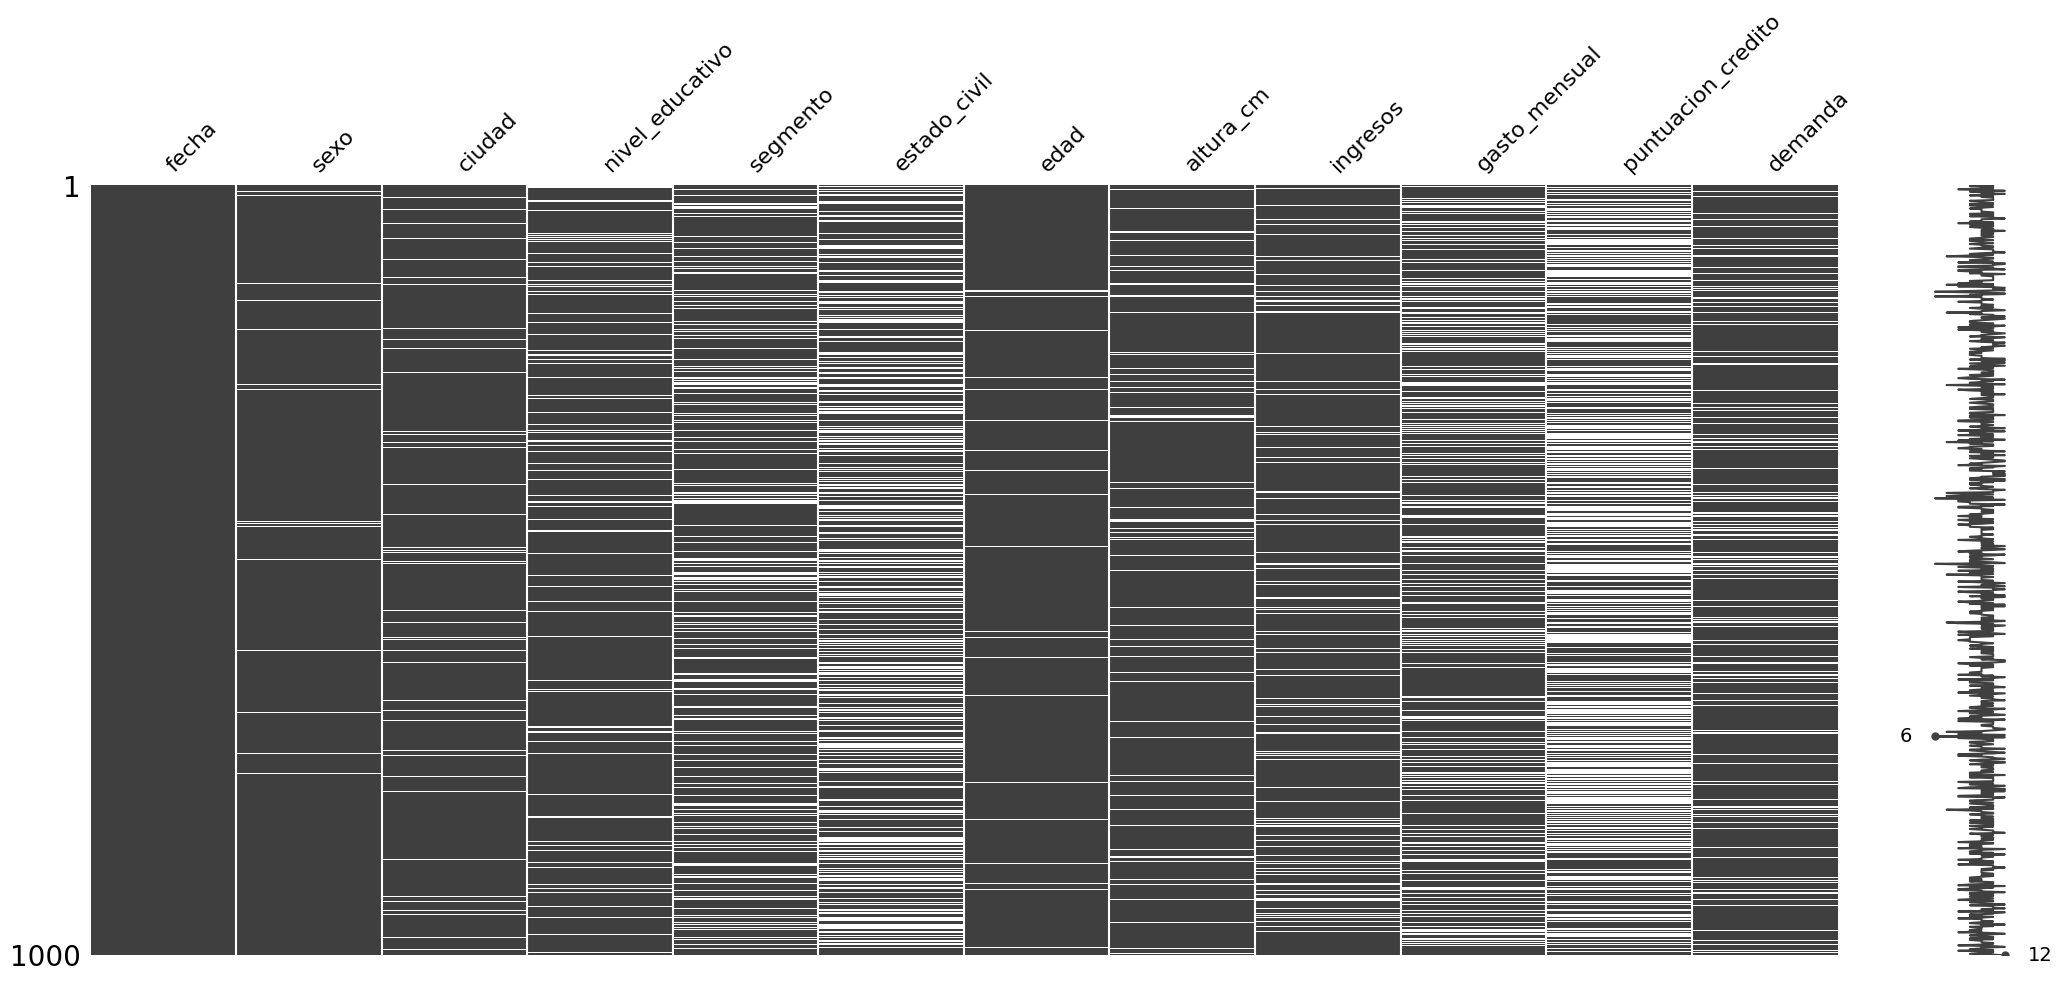

In [23]:
msno.matrix(df)
plt.show()

Mediante estas gráficas visualizamos los faltantes en cada variable, el porcentaje de los faltantes en diagrama de barras y un gráfico de calor, lo cual nos indican que los valores faltantes se concentran principalmente en las variables estado_civil y puntuacion_credito, mientras que en el resto se encuentran dispersos. Por lo que debemos clasificar e imputar variables. 

Ahora, las clasificamos de acuerdo a sus patrones:

| Variable            | % Nulos | Clasificación | Justificación breve                             |
| ------------------- | ------- | ------------- | ----------------------------------------------- |
| sexo                | 2%      | MCAR          | Errores aleatorios de registro                  |
| ciudad              | 5%      | MCAR          | Campo simple, bajo nivel de faltantes           |
| edad                | 3%      | MCAR          | Posible descuido, sin patrón evidente           |
| nivel\_educativo    | 10%     | MAR           | Depende de edad/segmento                        |
| segmento            | 20%     | MAR           | Relacionado con ingresos o clientes específicos |
| estado\_civil       | 35%     | MAR           | Depende de edad y sexo                          |
| altura\_cm          | 8%      | MAR           | Puede depender de sexo                          |
| ingresos            | 12%     | MAR           | Asociado a nivel educativo/segmento             |
| gasto\_mensual      | 25%     | MNAR          | Personas con gastos extremos no reportan        |
| puntuacion\_credito | 50%     | MNAR          | Falta cuando no hay historial o es negativo     |
| demanda             | 15%     | MNAR          | Puede faltar por no registrar compras           |
| fecha               | 0%     |No clasificación| Sin nulos                                       |


Para la variable fecha:
- ¿Se justifica imputar o dejar los nulos?
No aplica pues no hay nulos.

Para la variable sexo:

- ¿Se justifica imputar o dejar los nulos?
Imputar porque el porcentaje es bajo.

- ¿Qué riesgo tendría imputar esta variable?
Podría alterar un poco la proporción de hombres y mujeres.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Moda

Para la variable ciudad:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Concentrar demasiado los datos en una ciudad dominante.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Moda.

Para la variable nivel_educativo:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Falsear relaciones entre educación e ingresos.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Nueva categoría “Desconocido".

Para la variable segmento:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Alterar fuertemente la proporción de segmentos.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Categoría “Sin clasificar”.

Para la variable estado_civil:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Distorsionar patrones si se elige una sola categoría.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Categoría “No responde”.

Para la variable edad:

- ¿Se justifica imputar o dejar los nulos?
Imputar 

- ¿Qué riesgo tendría imputar esta variable?
Cambiar un poco la distribución si hay valores extremos.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Mediana

Para la variable altura_cm:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Reducir la variabilidad de la altura.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Mediana

Para la variable ingresos:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Sesgar el análisis financiero si se imputan valores poco realistas.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Mediana

Para la variable gasto_mensual:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Ocultar patrones reales de consumo.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Mediana 

Para la variable puntuacion_credito:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Que la mitad de los datos terminen “inventados”, perdiendo fiabilidad.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Modelos predictivos.

Para la variable demanda:

- ¿Se justifica imputar o dejar los nulos?
Imputar

- ¿Qué riesgo tendría imputar esta variable?
Suavizar demasiado los picos de demanda.

- ¿Qué técnica sería más adecuada (media, mediana, moda, interpolación, etc.)?
Interpolación

Con MCAR

In [29]:
from sklearn.impute import SimpleImputer
df_imputado = df.copy()

imp_moda = SimpleImputer(strategy="most_frequent")
imp_mediana = SimpleImputer(strategy="median")

# Las variables categóricas con moda
df_imputado[["sexo"]] = imp_moda.fit_transform(df[["sexo"]])
df_imputado[["ciudad"]] = imp_moda.fit_transform(df[["ciudad"]])

# Las variable numérica con mediana
df_imputado[["edad"]] = imp_mediana.fit_transform(df[["edad"]])


Con MAR

In [ ]:
from sklearn.impute import KNNImputer

# Variables cuantitativas relevantes
cuantitativas = ["edad", "altura_cm", "ingresos"]

imp_knn = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(
    imp_knn.fit_transform(df_imputado[cuantitativas]),
    columns=cuantitativas
)
df_imputado[cuantitativas] = df_knn[cuantitativas]

# nueva categoría
df_imputado["estado_civil"] = df_imputado["estado_civil"].fillna("No responde")


Con MNAR

In [ ]:
# nueva categoría
df_imputado["gasto_mensual"] = df_imputado["gasto_mensual"].fillna("No reporta")
# categoría especial
df_imputado["puntuacion_credito"] = df_imputado["puntuacion_credito"].fillna("Sin historial")
# Demanda: depende del rol
if "demanda" in df.columns:
    # si es predictor
    df_imputado["demanda"] = df_imputado["demanda"].fillna("No registrado")


In [33]:
resumen = pd.DataFrame({
    "Nulos antes": df.isna().sum(),
    "Nulos después": df_imputado.isna().sum(),
    "Total filas": len(df)
})
resumen["% antes"] = (resumen["Nulos antes"] / resumen["Total filas"] * 100).round(2)
resumen["% después"] = (resumen["Nulos después"] / resumen["Total filas"] * 100).round(2)
resumen = resumen[resumen["Nulos antes"] > 0]
print("Resumen de imputación:")
display(resumen)


Resumen de imputación:


,Nulos antes,Nulos después,Total filas,% antes,% después
sexo,20,0,1000,2.0,0.0
ciudad,50,0,1000,5.0,0.0
nivel_educativo,100,100,1000,10.0,10.0
segmento,200,200,1000,20.0,20.0
estado_civil,350,0,1000,35.0,0.0
edad,30,0,1000,3.0,0.0
altura_cm,80,0,1000,8.0,0.0
ingresos,120,0,1000,12.0,0.0
gasto_mensual,250,0,1000,25.0,0.0
puntuacion_credito,500,0,1000,50.0,0.0


Dado que el nivel educativo y el segmento son variables categóricas, crear una categoría adicional denominada “desconocido” o “sin información” preserva la naturaleza original de los datos y permite que el modelo estadístico reconozca estos casos sin distorsionar los patrones existentes.

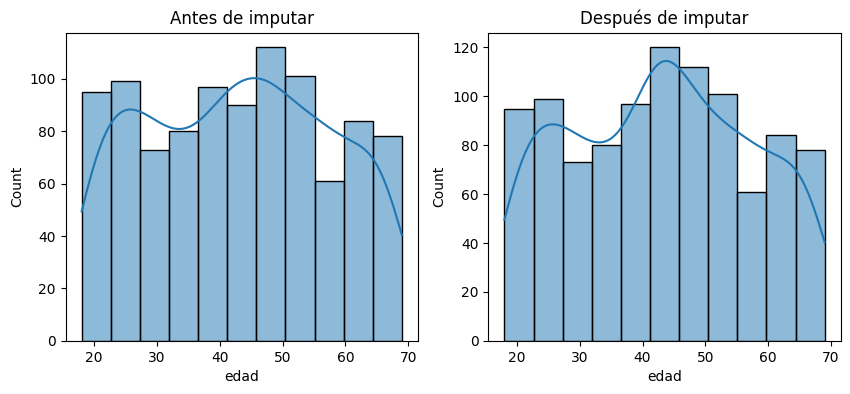

Shapiro original: ShapiroResult(statistic=0.9598269462585449, pvalue=1.1330513037074888e-15)
Shapiro imputada: ShapiroResult(statistic=0.9634751677513123, pvalue=3.966394405844134e-15)
Kolmogorov-Smirnov: KstestResult(statistic=0.015371134020618557, pvalue=0.9996769624500101, statistic_location=42.86185567010309, statistic_sign=-1)
Mann-Whitney U: MannwhitneyuResult(statistic=485360.0, pvalue=0.9772735005965205)


In [ ]:
import seaborn as sns
from scipy.stats import shapiro, ks_2samp, ttest_ind, mannwhitneyu

# Comparación de variable "edad"
original = df["edad"].dropna()
imputada = df_imputado["edad"]

# Histogramas antes y después
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(original, ax=axes[0], kde=True)
axes[0].set_title("Antes de imputar")
sns.histplot(imputada, ax=axes[1], kde=True)
axes[1].set_title("Después de imputar")
plt.show()

# Normalidad
print("Shapiro original:", shapiro(original))
print("Shapiro imputada:", shapiro(imputada))

# Igualdad de distribuciones
print("Kolmogorov-Smirnov:", ks_2samp(original, imputada))

if shapiro(original).pvalue > 0.05 and shapiro(imputada).pvalue > 0.05:
    print("t-test:", ttest_ind(original, imputada))
else:
    print("Mann-Whitney U:", mannwhitneyu(original, imputada))

La técnica de imputación aplicada preserva la distribución original de los datos mediante la prueba de Shapiro-Wilk, mostrando que tanto los datos originales como los imputados muestran valores de estadístico muy similares (0.960 vs 0.963) y valores p extremadamente bajos en ambos casos, indicando que la distribución no normal se mantiene consistentemente.

En la prueba de Kolmogorov-Smirnov el valor p de 0.9997 y el estadístico muy bajo indican que NO hay diferencias significativas entre las distribuciones original e imputada. No podemos rechazar la hipótesis nula de que ambas muestras provienen de la misma distribución.

Y la prueba de Mann-Whitney vemos que el valor p de 0.9773 confirma que no hay diferencias significativas en las medianas entre los datos originales e imputados.

In [ ]:
porcentaje = [0.0, 0.0, 0.0, 10.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

clasificacion = {
    "Clasificacion": ["-", "MCAR", "MCAR", "MAR", "MAR", "MNAR", 
                     "MCAR", "MCAR", "MAR", "MAR", "MNAR", "MCAR"]
}
decisiones = {
    'sexo': {'tecnica': 'Moda', 'tipo': 'categórica'},
    'ciudad': {'tecnica': 'Moda', 'tipo': 'categórica'},
    'nivel_educativo': {'tecnica': 'Regresión', 'tipo': 'categórica ordinal'},
    'segmento': {'tecnica': 'KNN (k=5)', 'tipo': 'categórica'},
    'estado_civil': {'tecnica': 'Imputación Múltiple', 'tipo': 'categórica'},
    'edad': {'tecnica': 'Media', 'tipo': 'numérica'},
    'altura_cm': {'tecnica': 'Media', 'tipo': 'numérica'},
    'ingresos': {'tecnica': 'Mediana', 'tipo': 'numérica'},
    'gasto_mensual': {'tecnica': 'Random Forest', 'tipo': 'numérica'},
    'puntuacion_credito': {'tecnica': 'Imputación Múltiple', 'tipo': 'numérica'},
    'demanda': {'tecnica': 'Media', 'tipo': 'numérica'}
}
tabla_resumen = pd.DataFrame({
    "Variable": df.columns,
    "PorcentajeNulos": porcentaje,
    "TipoAusencia": clasificacion["Clasificacion"],
    "MetodoImputacion": [decisiones.get(var, {}).get("tecnica", "Ninguno") for var in df.columns],
    "TipoVariable": [decisiones.get(var, {}).get("tipo", "-") for var in df.columns]
})
tabla_resumen = tabla_resumen[["Variable", "PorcentajeNulos", "TipoAusencia", "TipoVariable", "MetodoImputacion"]]
tabla_resumen

,Variable,PorcentajeNulos,TipoAusencia,TipoVariable,MetodoImputacion
0,fecha,0.0,-,-,Ninguno
1,sexo,0.0,MCAR,categórica,Moda
2,ciudad,0.0,MCAR,categórica,Moda
3,nivel_educativo,10.0,MAR,categórica ordinal,Regresión
4,segmento,20.0,MAR,categórica,KNN (k=5)
5,estado_civil,0.0,MNAR,categórica,Imputación Múltiple
6,edad,0.0,MCAR,numérica,Media
7,altura_cm,0.0,MCAR,numérica,Media
8,ingresos,0.0,MAR,numérica,Mediana
9,gasto_mensual,0.0,MAR,numérica,Random Forest


En todo este trabajo logramos identificar qué variables tenían datos faltantes y en qué proporción.

A partir de ese análisis se tomamos para las variables numéricas imputaciones con media o mediana dependiendo de la distribución. En variables categóricas se usó la moda y en algunos casos se dejó el nulo porque imputar podría distorsionar los resultados. No eliminamos filas completas pues se podía perder información importante.

Así, el dataset quedó limpio y listo para análisis posteriores junto con imputaciones justificadas según cada variable y con una estrategia que busca minimizar el riesgo de sesgos.

### **Imputaciones para series de tiempo**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Cargar los datos
url = "https://raw.githubusercontent.com/Kalbam/Datos/main/ts_imputacion_multivariada_masNA.csv"
df = pd.read_csv(url)

In [45]:
print(f"Dimensión: {df.shape}")
print(f"Valores faltantes por columna:")
missing_counts = df.isnull().sum()
print(missing_counts)
print(f"Porcentaje:")
print((missing_counts / len(df)) * 100)

Dimensión: (731, 9)
Valores faltantes por columna:
fecha            0
temperatura    107
humedad        115
lluvia_mm        0
precio          73
ventas         145
energia_kwh     60
sensor_A       119
sensor_B        96
dtype: int64
Porcentaje:
fecha           0.000000
temperatura    14.637483
humedad        15.731874
lluvia_mm       0.000000
precio          9.986320
ventas         19.835841
energia_kwh     8.207934
sensor_A       16.279070
sensor_B       13.132695
dtype: float64


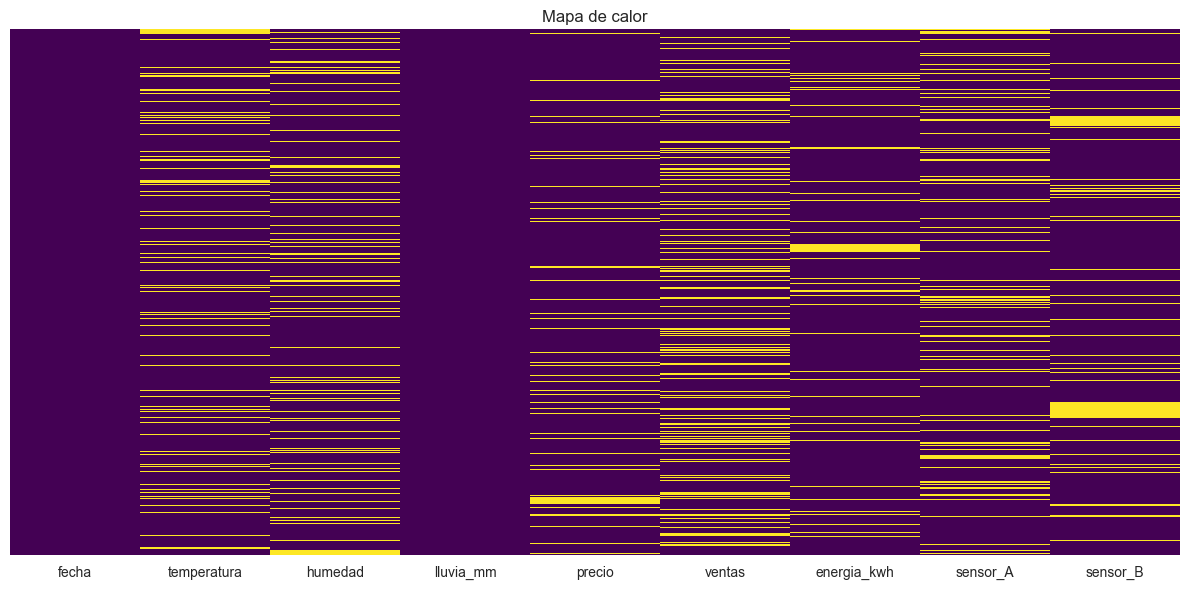

In [46]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de calor')
plt.tight_layout()
plt.show()

In [47]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
cols_con_na = [col for col in numeric_cols if df[col].isnull().sum() > 0]
print(f"Columnas numéricas con valores faltantes: {cols_con_na}")

Columnas numéricas con valores faltantes: ['temperatura', 'humedad', 'precio', 'ventas', 'energia_kwh', 'sensor_A', 'sensor_B']


Técnica a columnas con valores faltantes


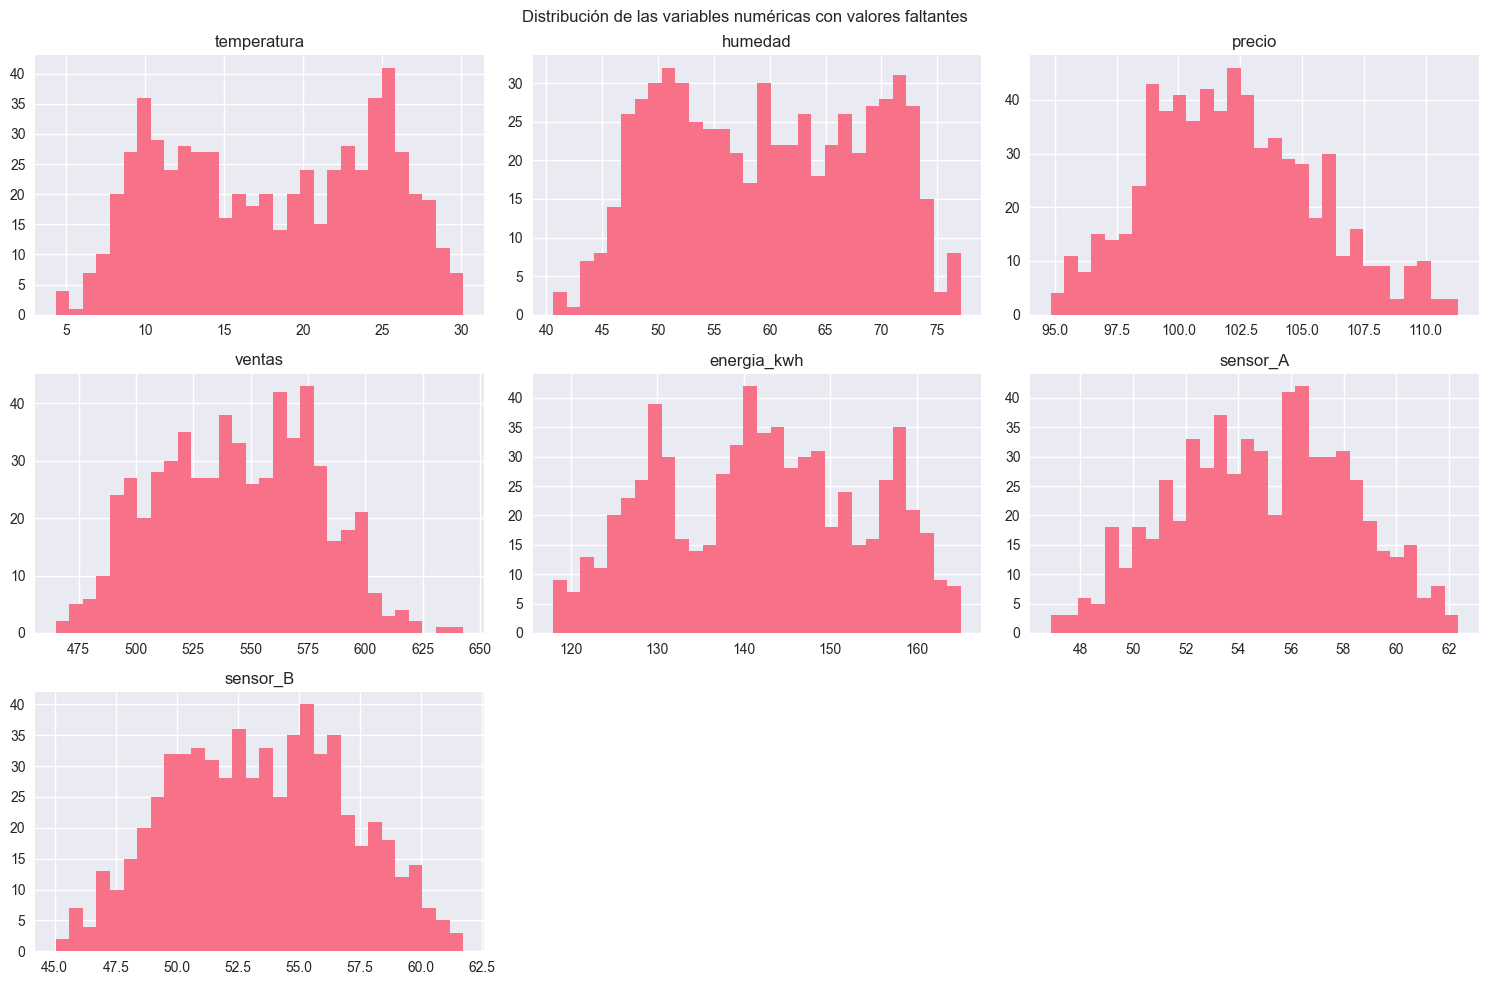

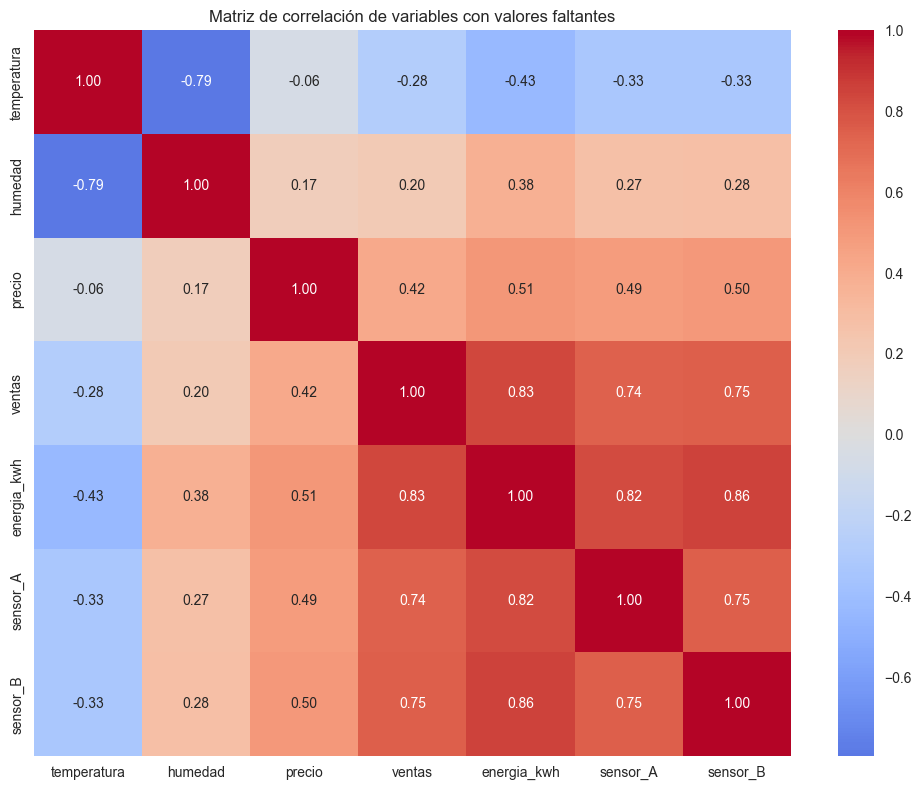

In [48]:
print("Técnica a columnas con valores faltantes")
if len(cols_con_na) > 0:
    #variables numéricas con NA's
    df[cols_con_na].hist(figsize=(15, 10), bins=30)
    plt.suptitle('Distribución de las variables numéricas con valores faltantes')
    plt.tight_layout()
    plt.show()

    # Matriz de correlación de variables con NA
    if len(cols_con_na) > 1:
        plt.figure(figsize=(10, 8))
        corr_matrix = df[cols_con_na].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Matriz de correlación de variables con valores faltantes')
        plt.tight_layout()
        plt.show()

# Técnicas de imputación
def evaluate_imputation(original, imputed, method_name):
    missing_mask = original.isnull()
    if missing_mask.sum() > 0:
        # Solo los valores faltantes
        valid_indices = ~missing_mask
        mse = mean_squared_error(original[valid_indices], imputed[valid_indices])
        mae = mean_absolute_error(original[valid_indices], imputed[valid_indices])
        return mse, mae
    return None, None

In [49]:
df_original = df.copy()
results = {}
imputed_dfs = {}
# Imputación con media
df_mean = df.copy()
for col in cols_con_na:
    df_mean[col].fillna(df[col].mean(), inplace=True)
imputed_dfs['media'] = df_mean

# Imputación con mediana
df_median = df.copy()
for col in cols_con_na:
    df_median[col].fillna(df[col].median(), inplace=True)
imputed_dfs['mediana'] = df_median

# Imputación KNN
if len(cols_con_na) > 0:
    knn_imputer = KNNImputer(n_neighbors=5)
    df_knn = df.copy()
    df_knn[cols_con_na] = knn_imputer.fit_transform(df[cols_con_na])
    imputed_dfs['knn'] = df_knn

# Imputación MICE
if len(cols_con_na) > 0:
    iterative_imputer = IterativeImputer(random_state=42, max_iter=10)
    df_mice = df.copy()
    df_mice[cols_con_na] = iterative_imputer.fit_transform(df[cols_con_na])
    imputed_dfs['mice'] = df_mice

# Interpolación
df_interp = df.copy()
for col in cols_con_na:
    df_interp[col] = df[col].interpolate(method='linear')
    df_interp[col] = df_interp[col].fillna(method='bfill').fillna(method='ffill')
imputed_dfs['interpolacion'] = df_interp



Evaluación para: temperatura
media           - MSE: 0.0000, MAE: 0.0000
mediana         - MSE: 0.0000, MAE: 0.0000
knn             - MSE: 0.0000, MAE: 0.0000
mice            - MSE: 0.0000, MAE: 0.0000
interpolacion   - MSE: 0.0000, MAE: 0.0000
Evaluación para: humedad
media           - MSE: 0.0000, MAE: 0.0000
mediana         - MSE: 0.0000, MAE: 0.0000
knn             - MSE: 0.0000, MAE: 0.0000
mice            - MSE: 0.0000, MAE: 0.0000
interpolacion   - MSE: 0.0000, MAE: 0.0000
Evaluación para: precio
media           - MSE: 0.0000, MAE: 0.0000
mediana         - MSE: 0.0000, MAE: 0.0000
knn             - MSE: 0.0000, MAE: 0.0000
mice            - MSE: 0.0000, MAE: 0.0000
interpolacion   - MSE: 0.0000, MAE: 0.0000
Evaluación para: ventas
media           - MSE: 0.0000, MAE: 0.0000
mediana         - MSE: 0.0000, MAE: 0.0000
knn             - MSE: 0.0000, MAE: 0.0000
mice            - MSE: 0.0000, MAE: 0.0000
interpolacion   - MSE: 0.0000, MAE: 0.0000
Evaluación para: energia_kwh
media    

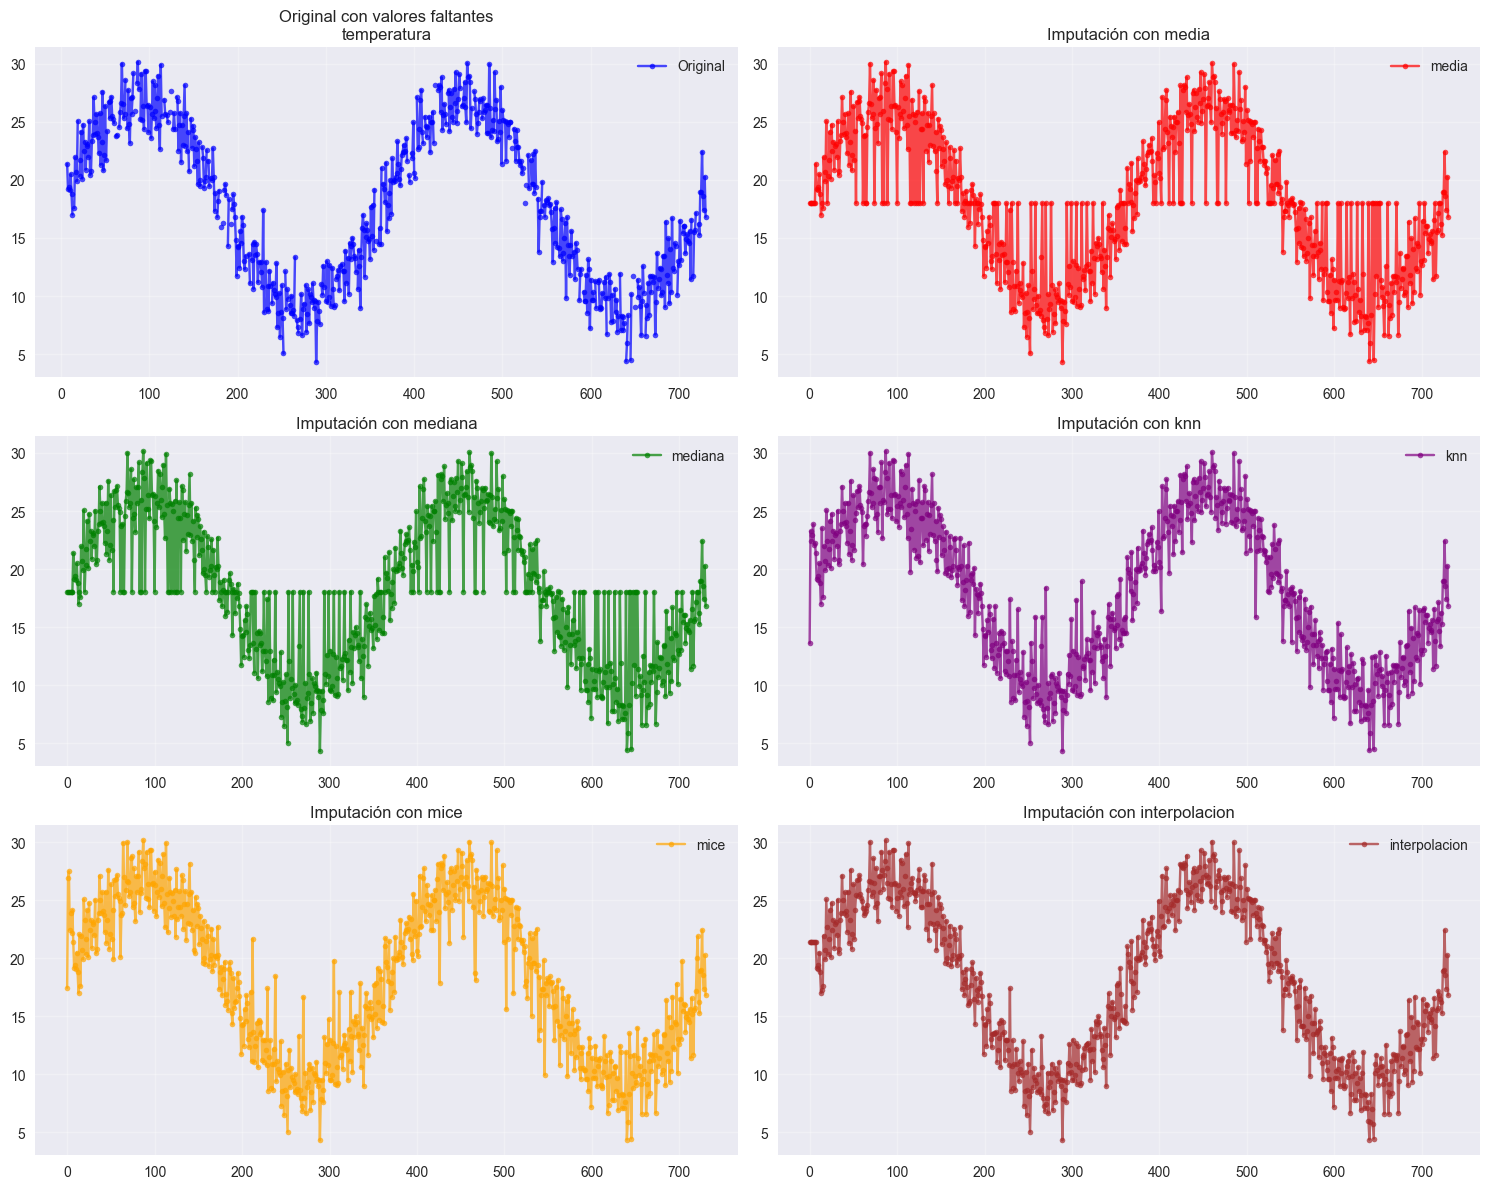

Resultados: 
Mejores métodos por columna:
temperatura          → media           (MSE: 0.0000, MAE: 0.0000)
humedad              → media           (MSE: 0.0000, MAE: 0.0000)
precio               → media           (MSE: 0.0000, MAE: 0.0000)
ventas               → media           (MSE: 0.0000, MAE: 0.0000)
energia_kwh          → media           (MSE: 0.0000, MAE: 0.0000)
sensor_A             → media           (MSE: 0.0000, MAE: 0.0000)
sensor_B             → media           (MSE: 0.0000, MAE: 0.0000)
Después de imputar:
Primeras 10 filas del dataset imputado:
        fecha  temperatura    humedad  lluvia_mm      precio  ventas  \
0  2023-01-01    18.004904  60.670000       0.00   99.680000   527.2   
1  2023-01-02    18.004904  48.960000       0.00  100.500000   493.7   
2  2023-01-03    18.004904  48.730000       0.00  100.860000   487.7   
3  2023-01-04    18.004904  57.130000       0.00  101.740000   512.8   
4  2023-01-05    18.004904  59.708506       2.79  101.770000   477.4   
5  2

In [52]:
if not cols_con_na:
    print("No hay columnas con valores faltantes para evaluar.")
else:
    for col in cols_con_na:
        print(f"Evaluación para: {col}")
        results[col] = {}
        for method_name, imputed_df in imputed_dfs.items():
            mse, mae = evaluate_imputation(df_original[col], imputed_df[col], method_name)
            if mse is not None:
                results[col][method_name] = {'mse': mse, 'mae': mae}
                print(f"{method_name:15} - MSE: {mse:.4f}, MAE: {mae:.4f}")

    # Visualización comparativa
    col_ejemplo = cols_con_na[0] if cols_con_na else None
    
    if col_ejemplo:
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        axes = axes.flatten()
        axes[0].plot(df_original[col_ejemplo], 'o-', alpha=0.7, label='Original', color='blue', markersize=4)
        axes[0].set_title(f'Original con valores faltantes\n{col_ejemplo}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        methods = list(imputed_dfs.keys())
        colors = ['red', 'green', 'purple', 'orange', 'brown']
        
        for i, (method, color) in enumerate(zip(methods, colors), 1):
            if i < len(axes):
                axes[i].plot(imputed_dfs[method][col_ejemplo], 'o-', alpha=0.7, 
                            label=method, color=color, markersize=4)
                axes[i].set_title(f'Imputación con {method}')
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        # Ocultar ejes vacíos si hay menos de 6 métodos
        for i in range(len(methods) + 1, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()

    # Análisis de resultados
    print("Resultados: ")
    # Encontrar el mejor método para cada columna
    best_methods = {}
    for col in results.keys():
        best_mse = float('inf')
        best_method = None
        for method, metrics in results[col].items():
            if metrics['mse'] < best_mse:
                best_mse = metrics['mse']
                best_method = method
        best_methods[col] = best_method

    print("Mejores métodos por columna:")
    for col, method in best_methods.items():
        mse = results[col][method]['mse']
        mae = results[col][method]['mae']
        print(f"{col:20} → {method:15} (MSE: {mse:.4f}, MAE: {mae:.4f})")
        
    print("Después de imputar:")
    df_final = df.copy()
    for col in best_methods.keys():
        best_method = best_methods[col]
        df_final[col] = imputed_dfs[best_method][col]

    print("Primeras 10 filas del dataset imputado:")
    print(df_final.head(10))

In [53]:
print("Resumen de imputación")
print(f"Dimensión antes: {df.shape}")
print(f"Variables numéricas: {len(numeric_cols)}")
print(f"Variables con valores faltantes: {len(cols_con_na)}")
print(f"Valores faltantes iniciales: {df.isnull().sum().sum()}")
print(f"Valores faltantes finales: {df_final.isnull().sum().sum() if 'df_final' in locals() else 'N/A'}")
print(f"Técnicas evaluadas: {list(imputed_dfs.keys())}")

if cols_con_na:
    print("Mejores métodos:")
    for col, method in best_methods.items():
        print(f"  - {col}: {method}")
else:
    print("No se encontraron columnas con valores faltantes para imputar.")

Resumen de imputación
Dimensión antes: (731, 9)
Variables numéricas: 8
Variables con valores faltantes: 7
Valores faltantes iniciales: 715
Valores faltantes finales: 0
Técnicas evaluadas: ['media', 'mediana', 'knn', 'mice', 'interpolacion']
Mejores métodos:
  - temperatura: media
  - humedad: media
  - precio: media
  - ventas: media
  - energia_kwh: media
  - sensor_A: media
  - sensor_B: media
